In [61]:
!pip install ipykernel pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

**1. ANALISIS RELEVANSI DATA BISNIS**<br>
- *kolom relevan: untuk kebutuhan data warehouse dan  analisis business intelligence (misal tren, profil demograsi, kinerja rpoduk, etc)*<br>
- *kolom irrlevan/redundan: merugikan performa BI jika di masukkan ke dalam OLAB cube/data warehouse*<br>
- Beserta alasan kritis teknis dan bisnis mengapa kolom tersebut harus di elim atau dipakai di skema data warehouse

In [62]:
# Lihat kolom dataset
df = pd.read_csv("AIKO YEREMI FERNANDA - Dataset Mentah Transaksi E-Commerce (100 Rows) - Tugas Pertemuan 3.xlsx - Dataset Mentah Transaksi E-Comm.csv")
print("Data berhasil dibaca.")

# Lihat tipe kolom
print("Kolom yang tersedia:", len(df.columns))
info_df = pd.DataFrame({
    "Nama Kolom": df.columns,
    "Tipe Data": df.dtypes.astype(str).values
})
display(info_df)

# Lihat sampel data
print("Menampilkan 5 sampel data.")
display(df.head())

Data berhasil dibaca.
Kolom yang tersedia: 15


,Nama Kolom,Tipe Data
0,Transaction_ID,str
1,Customer_ID,str
2,Customer_Name,str
3,Gender,str
4,Transaction_Date,str
5,Product_Category,str
6,Product_Name,str
7,Quantity,str
8,Unit_Price,str
9,Total_Amount,str


Menampilkan 5 sampel data.


,Transaction_ID,Customer_ID,Customer_Name,Gender,Transaction_Date,Product_Category,Product_Name,Quantity,Unit_Price,Total_Amount,Payment_Method,Shipping_Address,Internal_Server_IP,Temporary_Session_Token,Unnamed: 14
0,TXN-1001,CUST-02,Siti Aminah,P,2024-02-02,Elektronik,Headphone Bluetooth,3,450000,1350000,COD,"Jl. Soekarno Hatta No. 1, Malang",192.168.1.1,tok_sess_abc123xyz_001,NaN
1,TXN-1002,CUST-03,Joko Widodo,Perempuan,2024-02-03,E-L-E-K-T-R-O-N-I-K,Headphone Bluetooth,1,450000,450000,Credit Card,"Jl. Sudirman No. 2, Jakarta",192.168.1.2,tok_sess_abc123xyz_002,NaN
2,TXN-1003,CUST-04,Dewi Lestari,Male,2024-02-04,Elektronik,Laptop ASUS Vivobook,1,8500000,8500000,COD,"Jl. Soekarno Hatta No. 3, Malang",192.168.1.3,tok_sess_abc123xyz_003,NaN
3,TXN-1004,CUST-05,Rudi Hermawan,Perempuan,2024-02-05,Elektronik,Buku Pemrograman Python,2,120000,240000,credit_card,"Jl. Sudirman No. 4, Jakarta",192.168.1.4,tok_sess_abc123xyz_004,NaN
4,TXN-1005,CUST-06,Andi Wijaya,NaN,2024-02-06,Elektronik & Gadget,Buku Pemrograman Python,3,120000,360000,Transfer Bank,"Jl. Soekarno Hatta No. 5, Malang",192.168.1.5,tok_sess_abc123xyz_005,NaN


Dari Hasil overview data tersebut, relevansi data dapat dikategorikan menjadi 2:
1. **Kolom Relevan**: 
- Transaction_ID, Customer_ID, Customer_Name, Gender, Transaction_Date, Product_Category, Product_Name, Quantity, Unit_Price, Total_Amount, Payment_Method,  Shipping_Address.
- Alasan Bisnis: kolom-kolom ini sangat krusial untuk menjawab pertanyaan strategis perusahaan. Misalnya, mengetahui produk best seller tren performa produk(product_category, Quantity), siapa demografi pembeli terbanyak(gender), dan kapan puncak pendapatan terjadi(transaction_date, total_amount), dan lainnya.

2. **Kolom Inrelevan/Redundan**: 
- Internal_Server_IP, Temporary_Session_Token, Unnamed: 14
- Alasan Bisnis: Internal_Server_IP dan Temporary_Session_Token hanya data murni operasional sistem/jaringan jangka pendek. Tidak ada insight bisnis penjualan yang bisa diambil dari token sesi sementara pelanggan. Unnamed: 14 hanya kolom noise(sampah/redundan) yant tidak sengaja kesimpan akibat kesalahan. Tidak memiliki informasi dan hanya membuang memori database


**2. ANALISIS PROFILLING DATA & QUALITY ASSESSMENT**<br>
- **Analisis Profil Data :** Periksa seluruh kolom (14 column) data yg tersedia<br>
- **Indentifikasi Kualitas Data :** Evaluasi dataset berdasarkan 4 dimensi utama data quality:<br>
	- completeness: menemu-kenali data yang hilang/kosong
	- accuracy: menemu-kenali nilai yg tidak masuk akal
	- Consistency: menemu-kenali perbedaan format penulisan
	- validity & uniqueness: menemu-kali duplikasi primary key atau kesalahan struktur tipe data

In [63]:
# DATA PROFILLING
# -- Overview Umum ---
print("--- OVERVIEW UMUM ---")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
display(df.head(3))

# -- Structure Discovery---
print("\n--- STRUCTURE DISCOVERY ---")
# tipe data tiap kolom
print("\n-- Tipe Data --")
print(df.info())

# Panjang karakter untuk kolom teks (min, max, mean)
print("\n-- Panjang Karakter Kolom Teks --")
text_cols = df.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    lengths = df[col].dropna().astype(str).str.len()
    if len(lengths) > 0:
        print(f"{col}: min={lengths.min()}, max={lengths.max()}, mean={lengths.mean():.1f}")

# cek konsistensi format tanggal
print("\n-- Cek Format Tanggal --")
if 'Transaction_Date' in df.columns:
    # cek apakah bisa diparse sebagai tanggal
    parsed = pd.to_datetime(df['Transaction_Date'], errors='coerce', format='%Y-%m-%d')
    gagal_parsed = parsed.isnull() & df['Transaction_Date'].notnull() # yang gagal parsed tapi aslinya tidak NaN
    print(f"Jumlah baris dengan format tanggal tidak sesuai (YYYY-MM-DD): {gagal_parsed.sum()}")
    if gagal_parsed.sum() > 0:
        print("Contoh nilai bermasalah: ", df.loc[gagal_parsed, 'Transaction_Date'].unique()[:5])
    #cek apakah ada tanggal yang tidak masuk akal (masa depan atau terlalu lampau)
    print(f"Rentang tanggal: {parsed.min()} s/d {parsed.max()}")

# cek pola format khusus (ID)
print("\n-- Cek Pola Format ID--")
# cek pola/format khusus Transaction_ID
if 'Transaction_ID' in df.columns:
    pattern_txn = r'^TXN-\d{4}$'
    invalid_txn = ~df['Transaction_ID'].astype(str).str.match(pattern_txn)
    print(f"Transaction_ID tidak sesuai format 'TXN-###': {invalid_txn.sum()}")
    if invalid_txn.sum()>0:
        print("Contoh nilai bermasalah: ", df.loc[invalid_txn, 'Transaction_ID'].unique()[:5])

# cek pola/format khusus Customer_ID
if 'Customer_ID' in df.columns:
    pattern_cust = r'^CUST-\d{2}$'
    invalid_cust = ~df['Customer_ID'].astype(str).str.match(pattern_cust)
    print(f"Customer_ID tidak sesuai format 'CUST-##': {invalid_cust.sum()} baris")
    if invalid_cust.sum() > 0:
        print("Contoh nilai bermasalah: ", df.loc[invalid_cust, 'Customer_ID'].unique()[:5])

--- OVERVIEW UMUM ---
Jumlah baris: 100, Jumlah kolom: 15


,Transaction_ID,Customer_ID,Customer_Name,Gender,Transaction_Date,Product_Category,Product_Name,Quantity,Unit_Price,Total_Amount,Payment_Method,Shipping_Address,Internal_Server_IP,Temporary_Session_Token,Unnamed: 14
0,TXN-1001,CUST-02,Siti Aminah,P,2024-02-02,Elektronik,Headphone Bluetooth,3,450000,1350000,COD,"Jl. Soekarno Hatta No. 1, Malang",192.168.1.1,tok_sess_abc123xyz_001,NaN
1,TXN-1002,CUST-03,Joko Widodo,Perempuan,2024-02-03,E-L-E-K-T-R-O-N-I-K,Headphone Bluetooth,1,450000,450000,Credit Card,"Jl. Sudirman No. 2, Jakarta",192.168.1.2,tok_sess_abc123xyz_002,NaN
2,TXN-1003,CUST-04,Dewi Lestari,Male,2024-02-04,Elektronik,Laptop ASUS Vivobook,1,8500000,8500000,COD,"Jl. Soekarno Hatta No. 3, Malang",192.168.1.3,tok_sess_abc123xyz_003,NaN



--- STRUCTURE DISCOVERY ---

-- Tipe Data --
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Transaction_ID           99 non-null     str  
 1   Customer_ID              97 non-null     str  
 2   Customer_Name            100 non-null    str  
 3   Gender                   98 non-null     str  
 4   Transaction_Date         99 non-null     str  
 5   Product_Category         100 non-null    str  
 6   Product_Name             100 non-null    str  
 7   Quantity                 100 non-null    str  
 8   Unit_Price               99 non-null     str  
 9   Total_Amount             100 non-null    str  
 10  Payment_Method           98 non-null     str  
 11  Shipping_Address         99 non-null     str  
 12  Internal_Server_IP       100 non-null    str  
 13  Temporary_Session_Token  99 non-null     str  
 14  Unnamed: 14             


--- CONTENT DISCOVERY ---

-- Statistik Deskriptif (Numerik) --


,Quantity,Unit_Price,Total_Amount
count,98.000000,9.700000e+01,9.900000e+01
mean,104.979592,2.070155e+06,5.134424e+07
std,1009.751689,3.246499e+06,4.517604e+08
min,-2.000000,-5.000000e+05,-7.000000e+06
25%,2.000000,7.500000e+04,2.400000e+05
50%,3.000000,1.500000e+05,6.000000e+05
75%,4.000000,3.500000e+06,7.000000e+06
max,9999.000000,8.500000e+06,4.499550e+09



-- statistik Deskriptif (Kategorikal) --


,Transaction_ID,Customer_ID,Customer_Name,Gender,Transaction_Date,Product_Category,Product_Name,Payment_Method,Shipping_Address,Internal_Server_IP,Temporary_Session_Token,Unnamed: 14
count,99,97,100,98,99,100,100,98,99,100,99,2
unique,96,10,21,7,32,9,8,10,99,100,99,2
top,TXN-1007,CUST-02,Andi Wijaya,Perempuan,2024-02-02,Elektronik,Kaos Polos Cotton,Credit Card,"Jl. Soekarno Hatta No. 1, Malang",192.168.1.1,tok_sess_abc123xyz_001,tok_sess_abc123xyz_020
freq,2,10,10,27,4,19,23,22,1,1,1,1



-- Missing Value --


,jumlah_missing,persen_missing
Transaction_ID,1,1.0
Customer_ID,3,3.0
Gender,2,2.0
Transaction_Date,1,1.0
Quantity,2,2.0
Unit_Price,3,3.0
Total_Amount,1,1.0
Payment_Method,2,2.0
Shipping_Address,1,1.0
Temporary_Session_Token,1,1.0


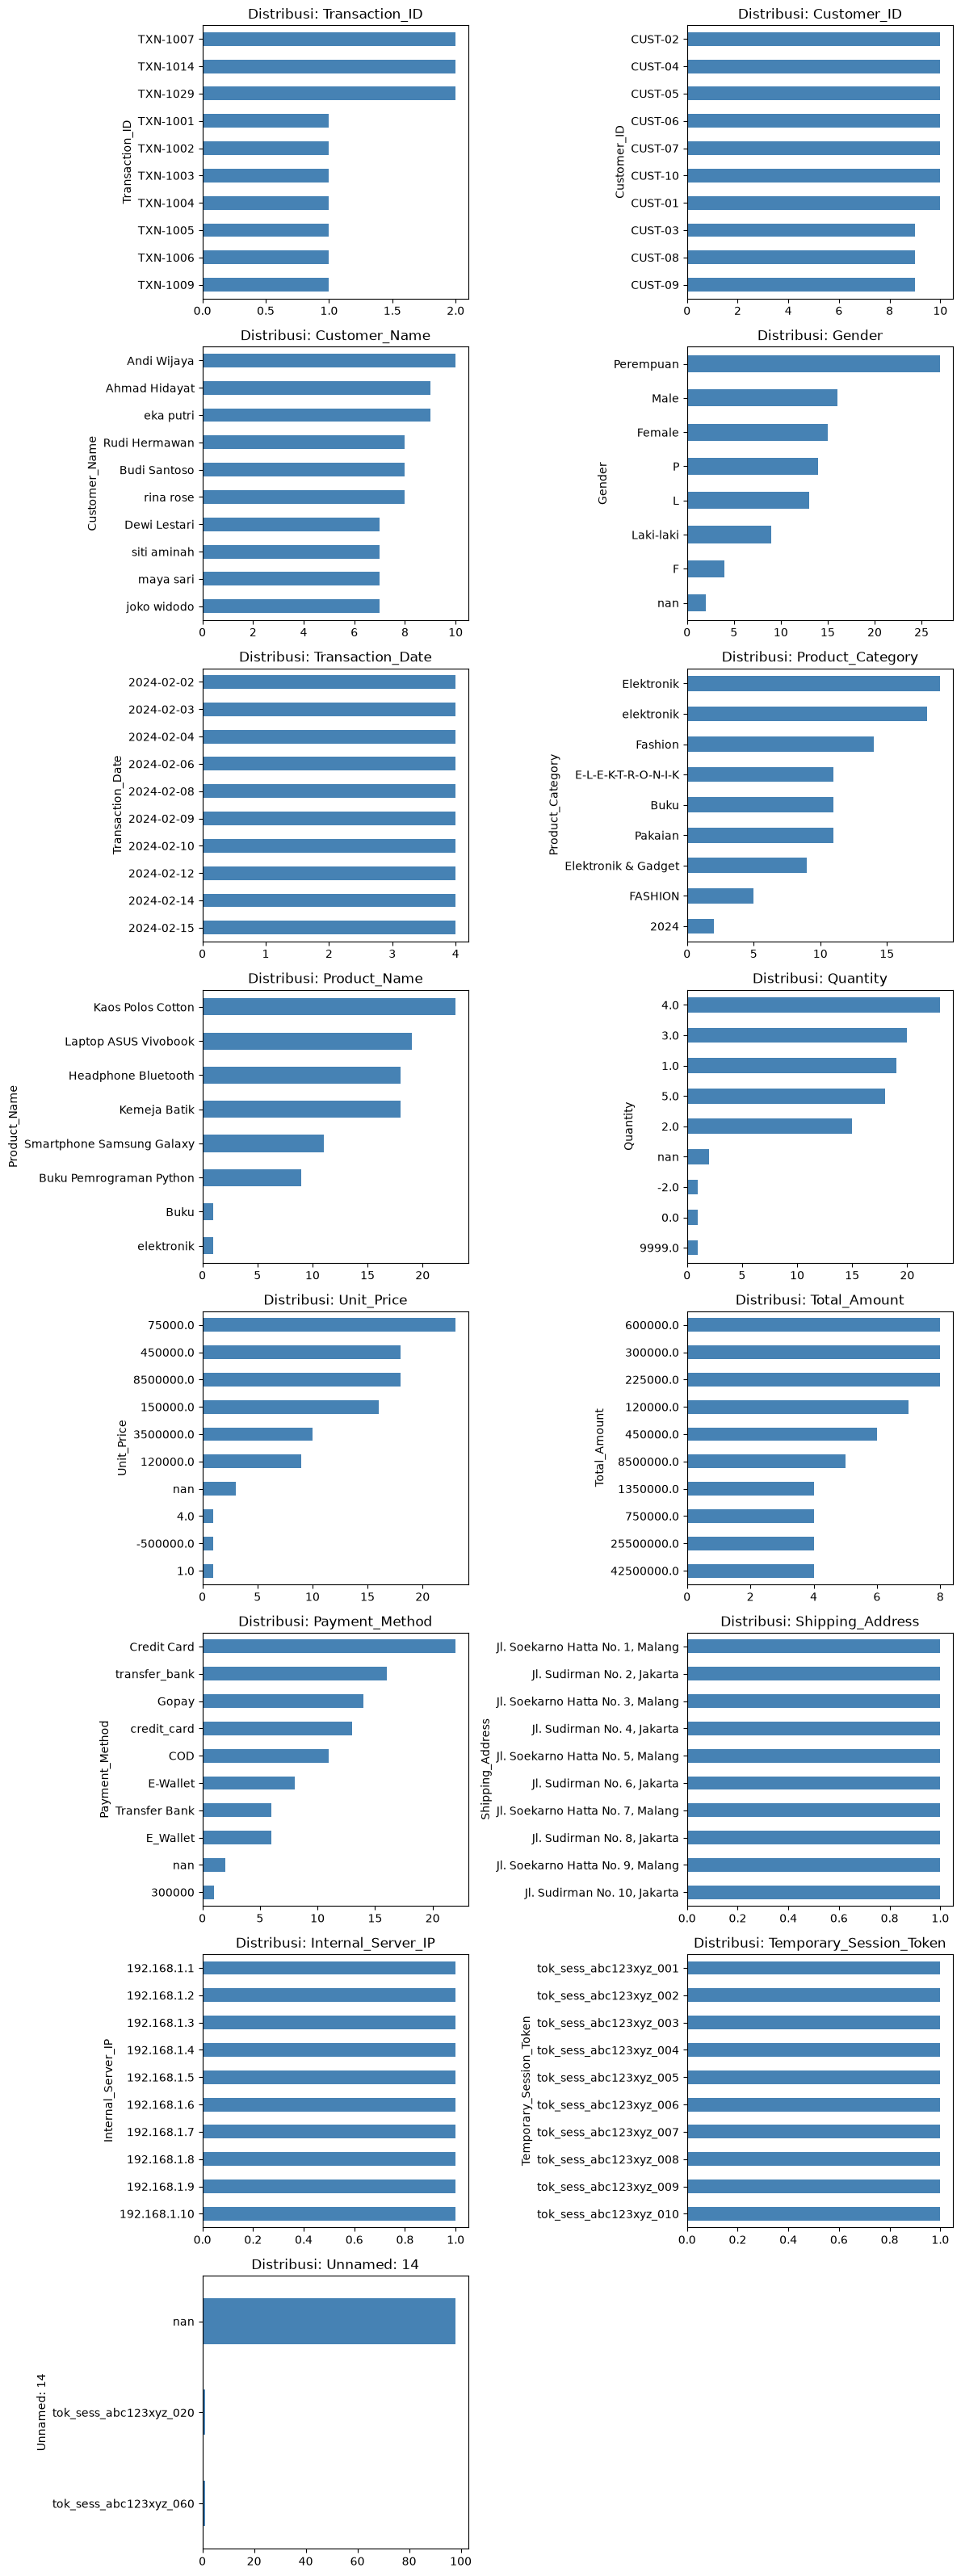


-- Deteksi Outlier (IQR) --
Quantity: min=-2.0, max=9999.0, rata-rata=104.98, outlier=2
Unit_Price: min=-500000.0, max=8500000.0, rata-rata=2070154.69, outlier=0
Total_Amount: min=-7000000.0, max=4499550000.0, rata-rata=51344242.42, outlier=13


In [74]:
# -- Content Discovery---
print("\n--- CONTENT DISCOVERY ---")
# statistik deskriptif kolom numerik
print("\n-- Statistik Deskriptif (Numerik) --")
display(df.describe())
# statistik deskriptif kolom kategorikal
print("\n-- statistik Deskriptif (Kategorikal) --")
display(df.describe(include=['object', 'string']))

# Missing value per kolom
print("\n-- Missing Value --")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    'jumlah_missing': missing, 
    'persen_missing': missing_pct
})
display(missing_summary[missing_summary['jumlah_missing'] > 0])

# Distribusi frekuensi untuk kolom kategorikal (top values)
'''
print("\n-- Distribusi Frekuensi Kolom Kategorikal --")
for col in text_cols:
    print(f"\n{col}: ")
    print(df[col].value_counts(dropna=False).head(10))
'''
n_cols = len(text_cols)
n_rows = math.ceil(n_cols / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(text_cols):
    value_counts = df[col].value_counts(dropna=False).head(10)
    value_counts.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"Distribusi: {col}")
    axes[i].invert_yaxis()

# hapus subplot kosong kalau jumlah kolom ganjil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Deteksi outlier / nilai ekstrem (metode IQR) untuk kolom numerik
print("\n-- Deteksi Outlier (IQR) --")
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, rata-rata={df[col].mean():.2f}, outlier={outliers}")

In [65]:
# --- Relationship Discovery ---
print("\n--- RELATIONSHIP DISCOVERY ---")
# cek keunikan primary key (harus 100% unik, tidak boleh duplikat)
print("\n-- Cek Primary Key --")
possible_pk = [c for c in df.columns if 'id' in c.lower()]
for col in possible_pk:
    n_unique = df[col].nunique()
    n_total = df[col].notnull().sum()
    status = "VALID (unik)" if n_unique == n_total else f"BERMASALAH ({n_total - n_unique} duplikat)"
    print(f"{col}: {n_unique} unik dari {n_total} baris -> {status}")

# cek relasi logis customer ID dengan customer nama
print("\n-- Cek Konsistensi Internal (ID dan nama Customer) --")
if 'Customer_ID' in df.columns and 'Customer_Name' in df.columns:
    # cek apakah 1 ID punya lebih dari 1 nama customer
    inconsistent = df.groupby('Customer_ID')['Customer_Name'].nunique()
    bermasalah = inconsistent[inconsistent > 1]
    if len(bermasalah>0):
        print(f"Ditemukan {len(bermasalah)} Customer_ID dengan lebih dari 1 nama berbeda: ")
        print(bermasalah)
    else:
        print("Tidak ditemukan Customer_ID dengan nama yang tidak konsisten.")


--- RELATIONSHIP DISCOVERY ---

-- Cek Primary Key --
Transaction_ID: 96 unik dari 99 baris -> BERMASALAH (3 duplikat)
Customer_ID: 10 unik dari 97 baris -> BERMASALAH (87 duplikat)

-- Cek Konsistensi Internal (ID dan nama Customer) --
Ditemukan 9 Customer_ID dengan lebih dari 1 nama berbeda: 
Customer_ID
CUST-01    3
CUST-02    2
CUST-03    2
CUST-04    3
CUST-05    3
CUST-07    3
CUST-08    2
CUST-09    2
CUST-10    2
Name: Customer_Name, dtype: int64


In [66]:
# DATA QUALITY ASSESSMENT
# Completeness
print("--- COMPLETENESS ---")
# missing value
print("Persentase Missing Value per Kolom:")
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
if missing_data.empty:
    print("Tidak ada missing value.")
else:
    print(missing_data.round(2).astype(str) + '%')

--- COMPLETENESS ---
Persentase Missing Value per Kolom:
Unnamed: 14                98.0%
Customer_ID                 3.0%
Gender                      2.0%
Payment_Method              2.0%
Transaction_ID              1.0%
Transaction_Date            1.0%
Unit_Price                  1.0%
Shipping_Address            1.0%
Temporary_Session_Token     1.0%
dtype: str


In [67]:
# Validity & Uniqueness
print("\n--- VALIDITY & UNIQUENESS ---")
# Uniqueness(duplikasi data & primary key)
print("Jumlah baris duplikat (semua kolom): ", df.duplicated().sum())
if 'Transaction_ID' in df.columns:
    dup_pk = df['Transaction_ID'].duplicated().sum()
    dup_mask = df['Transaction_ID'].duplicated(keep=False)
    dup_data = df[dup_mask]
    print(f"Jumlah duplikasi Primary Key: {dup_pk}", )
    print(dup_data[['Transaction_ID', 'Customer_ID', 'Transaction_Date']])
# Validity (cek tipe data & struktur)
print("\nTipe data tiap kolom sebelum perbaikan: ")
print(df.dtypes)
# konversi kolom yang seharusnya numerik (masing2 tiap kolomnya sendiri)
for col in ['Quantity', 'Unit_Price', 'Total_Amount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nJumlah nilai yang gagal dikonversi ke numerik (jadi Nan) per kolom:")
for col in ['Quantity', 'Unit_Price', 'Total_Amount']:
    if col in df.columns:
        print(f"{col}: {df[col].isnull().sum()}")

# cek validitas nilai (logika tidak bole negatif, harus huruf bukan full angka, tanggal, etc)
if 'Unit_Price' in df.columns:
    print("\nTransaksi dengan harga produk negatif: ", (df['Unit_Price']<0).sum())
if 'Quantity' in df.columns:
    print("Transaksi dengan quantity negatif: ", (df['Quantity']<0).sum())
if 'Total_Amount' in df.columns:
    print("Transaksi dengan total harga negatif: ", (df['Total_Amount']<0).sum())
if 'Transaction_Date' in df.columns:
    invalid_dates = pd.to_datetime(df['Transaction_Date'], errors='coerce').isnull().sum()
    print("Jumlah tanggal dengan format tidak valid: ", invalid_dates)

text_columns = ['Product_Category', 'Payment_Method', 'Gender', 'Costumer_name']
for col in text_columns:
    if col in df.columns:
        is_fully_numeric = df[col].astype(str).str.strip().str.match(r'^\d+$')
        jumlah_anomali = is_fully_numeric.sum()
    if jumlah_anomali > 0:
        print(f"\nKolom '{col}': {jumlah_anomali} baris berisi full angka seharusnya huruf")
        print("Contoh nilai bermasalah:", df.loc[is_fully_numeric, col].unique()[:5])
    else:
        print(f"\nKolom '{col}: Aman, tidak ada yang full angka")


--- VALIDITY & UNIQUENESS ---
Jumlah baris duplikat (semua kolom):  0
Jumlah duplikasi Primary Key: 3
   Transaction_ID Customer_ID Transaction_Date
6        TXN-1007     CUST-08       2024-02-08
7        TXN-1007     CUST-09       2024-02-09
13       TXN-1014     CUST-05       2024-02-15
14       TXN-1014     CUST-06       2024-02-16
28       TXN-1029     CUST-10       2024-02-02
29       TXN-1029     CUST-01       2024-02-03

Tipe data tiap kolom sebelum perbaikan: 
Transaction_ID             str
Customer_ID                str
Customer_Name              str
Gender                     str
Transaction_Date           str
Product_Category           str
Product_Name               str
Quantity                   str
Unit_Price                 str
Total_Amount               str
Payment_Method             str
Shipping_Address           str
Internal_Server_IP         str
Temporary_Session_Token    str
Unnamed: 14                str
dtype: object

Jumlah nilai yang gagal dikonversi ke numerik 

In [68]:
# Accuracy
print("\n--- ACCURACY ---")
# statistik deskriptif kolom numerik
print("\nStatistik deskriptif kolom numerik:")
display(df.describe())
# deteksi outlier/nilai tidak masuk akal pakai metode IQR
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 - 1.5 * IQR
    outlier_count = ((df[col]<lower) | (df[col]>upper)).sum()
    if outlier_count > 0:
        print(f"{col}: {outlier_count} outlier terdeteksi (di luar rentang {lower:.2f} - {upper:.2f})")


--- ACCURACY ---

Statistik deskriptif kolom numerik:


,Quantity,Unit_Price,Total_Amount
count,98.000000,9.700000e+01,9.900000e+01
mean,104.979592,2.070155e+06,5.134424e+07
std,1009.751689,3.246499e+06,4.517604e+08
min,-2.000000,-5.000000e+05,-7.000000e+06
25%,2.000000,7.500000e+04,2.400000e+05
50%,3.000000,1.500000e+05,6.000000e+05
75%,4.000000,3.500000e+06,7.000000e+06
max,9999.000000,8.500000e+06,4.499550e+09


Quantity: 78 outlier terdeteksi (di luar rentang -1.00 - 1.00)
Unit_Price: 97 outlier terdeteksi (di luar rentang -5062500.00 - -1637500.00)
Total_Amount: 98 outlier terdeteksi (di luar rentang -9900000.00 - -3140000.00)



--- CONSISTENCY ---

Kolom 'Customer_Name' punya kemungkinan inkonsistensi format penulisan:
['  Rudi Hermawan ', '  rina rose ', 'Budi Santoso', 'Dewi Lestari', 'Eka Putri', 'Joko Widodo', 'Maya Sari', 'Rina Rose', 'Rudi Hermawan', 'Siti Aminah', 'budi santoso', 'dewi lestari', 'eka putri', 'joko widodo', 'maya sari', 'rina rose', 'siti aminah']

Kolom 'Product_Category' punya kemungkinan inkonsistensi format penulisan:
['Elektronik', 'FASHION', 'Fashion', 'elektronik']

Cek nilai unik setiap kolom kategorikal (deteksi manual):

Kolom 'Customer_ID' (10 nilai unik):
Customer_ID
CUST-02    10
CUST-04    10
CUST-05    10
CUST-06    10
CUST-07    10
CUST-10    10
CUST-01    10
CUST-03     9
CUST-08     9
CUST-09     9
NaN         3
Name: count, dtype: int64

Kolom 'Gender' (7 nilai unik):
Gender
Perempuan    27
Male         16
Female       15
P            14
L            13
Laki-laki     9
F             4
NaN           2
Name: count, dtype: int64

Kolom 'Product_Category' (9 nilai unik):

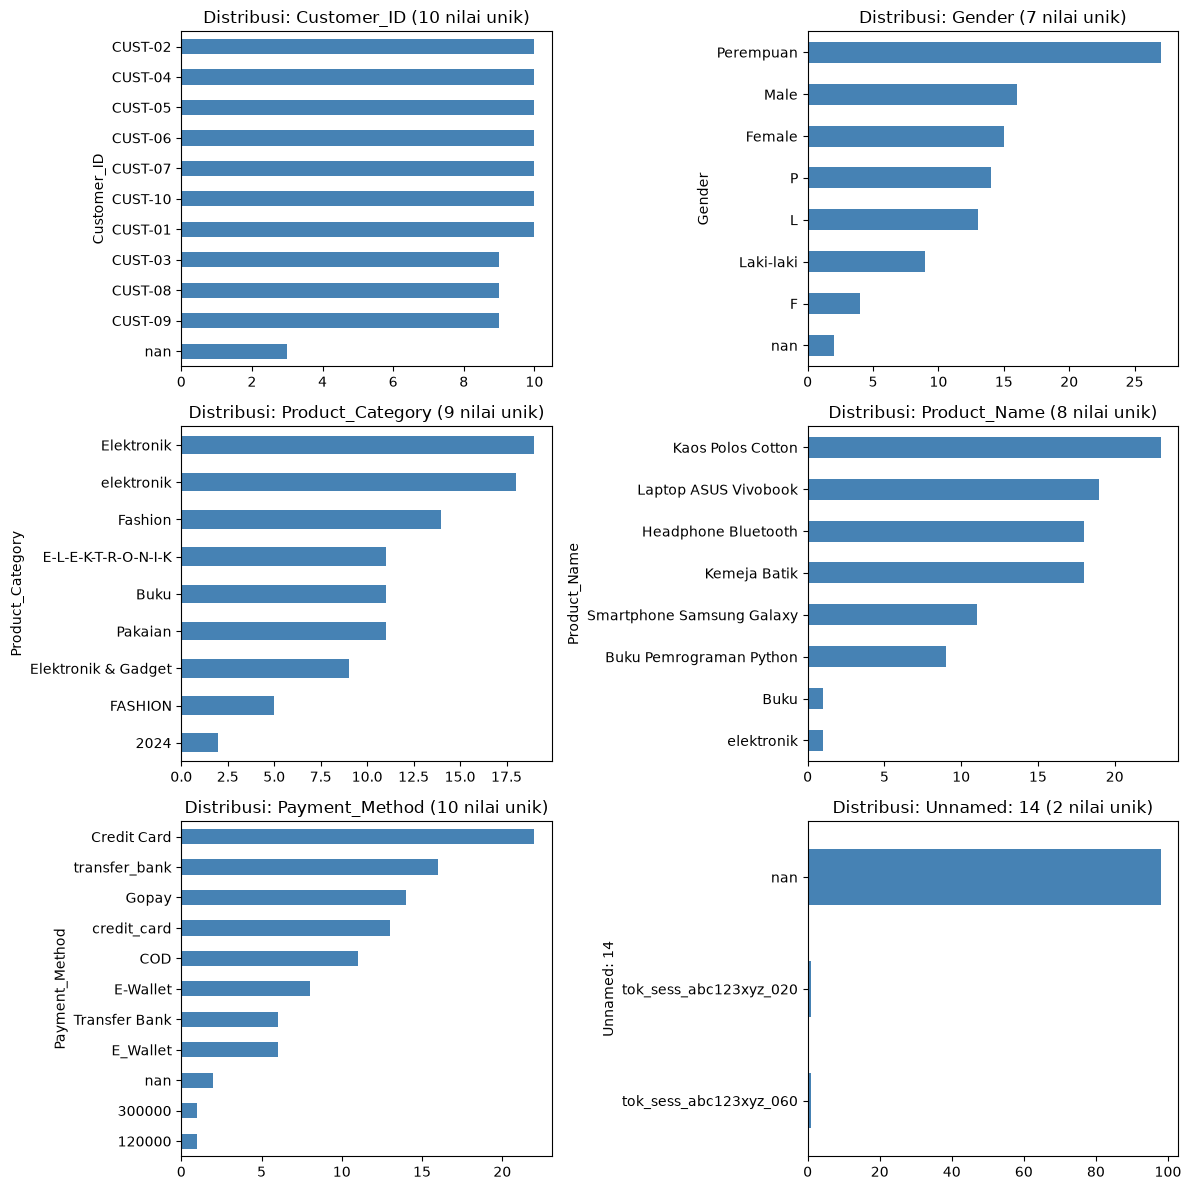

In [75]:
# Consistency
print("\n--- CONSISTENCY ---")
# Cek perbedaan format penulisan pada kolom kategorikal/teks
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    # Bandingkan versi lowercase & strip untuk cari kemungkinan duplikasi format
    normalized = pd.Series(unique_vals).str.lower().str.strip()
    if normalized.duplicated().sum() > 0:
        print(f"\nKolom '{col}' punya kemungkinan inkonsistensi format penulisan:")
        dupes = normalized[normalized.duplicated(keep=False)]
        # tampilkan nilai asli yang mirip
        mirip = [v for v in unique_vals if str(v).lower().strip() in dupes.values]
        print(sorted(set(mirip)))

print("\nCek nilai unik setiap kolom kategorikal (deteksi manual):")

# filter dulu kolom mana saja yang punya <=20 nilai unik
cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 20]

# print value_counts seperti biasa
for col in cols_to_plot:
    n_unique = df[col].nunique()
    print(f"\nKolom '{col}' ({n_unique} nilai unik):")
    print(df[col].value_counts(dropna=False))

# visualisasi dalam 1 grid
if len(cols_to_plot) > 0:
    n_cols = len(cols_to_plot)
    n_rows = math.ceil(n_cols / 2)

    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]

    for i, col in enumerate(cols_to_plot):
        value_counts = df[col].value_counts(dropna=False)
        value_counts.plot(kind='barh', ax=axes[i], color='steelblue')
        axes[i].set_title(f"Distribusi: {col} ({df[col].nunique()} nilai unik)")
        axes[i].invert_yaxis()

    # hapus subplot kosong kalau jumlah kolom ganjil
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom kategorikal dengan <=20 nilai unik.")


In [70]:
# OVER VIEW

In [71]:
# EDA

In [72]:
# PREPROCESSING

In [73]:
# MODELING